# 1D Burgers Equation DEMO code

This notebook demonstrates solving 1D Burgers Equation (spatial xy version) using PINNs.

In [1]:
import deepflow as df
print("Deepflow is runned on:", df.device) # to change to cpu use df.device = 'cpu'
df.manual_seed(69) # for reproducibility

Deepflow is runned on: cuda


## 1. Define Geometry Domain
Set up the computational domain

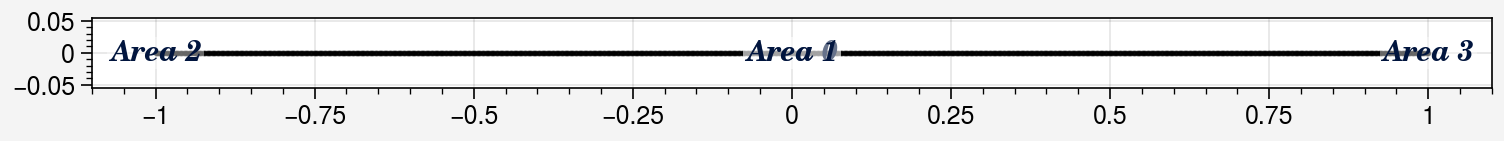

In [2]:
import torch
area1 = df.custom_data({'x': torch.linspace(-1, 1, 1000), 'y': torch.zeros(1000)})
area2 = df.custom_data({'x': torch.linspace(-1, 1, 1000), 'y': torch.zeros(1000)})
dot1 = df.custom_data({'x': torch.tensor([-1.0]), 'y': torch.tensor([0.0])})
dot2 = df.custom_data({'x': torch.tensor([1.0]), 'y': torch.tensor([0.0])})
domain = df.domain(area1, area2, dot1, dot2)
domain.show_coordinates(display_physics=True)

In [3]:
class HeatEquation1D(df.PDE):
    """
    1D Heat Equation: u_t = alpha * u_xx
    """
    def __init__(self, alpha: float):
        super().__init__()
        self.alpha = alpha

    def compute_residuals(self, inputs_dict):
        x = inputs_dict['x']
        t = inputs_dict['t']
        u = inputs_dict['u']

        # First derivatives
        u_x, u_t = df.calc_grads(u, (x, t))

        # Second derivatives
        u_xx = df.calc_grad(u_x, x)

        # Residual
        heat_residual = u_t - self.alpha * u_xx

        self.residual_fields = (heat_residual,)
        return self.residual_fields

## 2. Define Physics
Define the Burgers eq (spatial version) apply boundary conditions.

In [4]:
# Define PDE
domain.area_list[0].define_pde(HeatEquation1D(alpha=0.01))
domain.area_list[1].define_ic({'u': 0})
domain.area_list[2].define_bc({'u': 0})
domain.area_list[3].define_bc({'u': 1})
for g in  domain:
    print(g.physics_type)
    g.define_time([0,0.5])
    g.sampling_time()
    g.process_coordinates()

PDE
IC
b
BC
b
BC
b


C:\Users\thamm\OneDrive\Documents\1 - Projects\0 - STEM\2 - Numerical Physics\9 - PINNs\deepflow\src\deepflow\physicsinformed.py:116: UserWarning: Sampling has not yet defined. Uniform scheme is used.
  warnings.warn("Sampling has not yet defined. Uniform scheme is used.")
C:\Users\thamm\OneDrive\Documents\1 - Projects\0 - STEM\2 - Numerical Physics\9 - PINNs\deepflow\src\deepflow\physicsinformed.py:122: UserWarning: expo_scaling has not yet defined. False is set as default.
  warnings.warn("expo_scaling has not yet defined. False is set as default.")


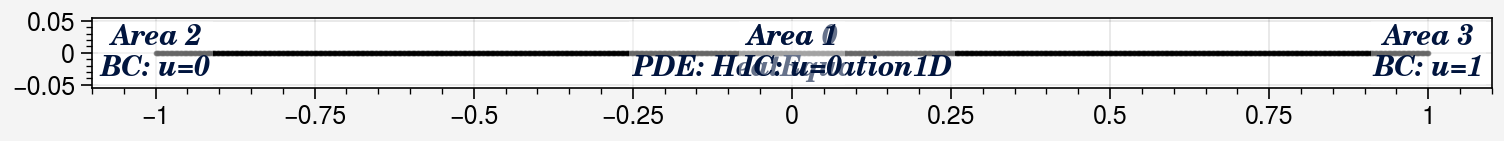

In [5]:
domain.show_coordinates(display_physics=True)

### 2. Generate Training Data

Sample initial points for training. After sampling, Deepflow will automatically generate training datasets based on the defined physics.

### 3. Train the Model

Define the resampling scheme during training. [R3](https://arxiv.org/abs/2207.02338) scheme is recommended.

Train the model using Adam optimizer followed by L-BFGS optimizer.

In [6]:
model0 = df.PINN(input_vars=['x', 't'], output_vars=['u'], width=16, length=4)

model1, model1_best = model0.train_adam(
    calc_loss = df.calc_loss_weighted(domain, bc_weights=1),
    learning_rate=0.004,
    epochs=1200)

Epoch: 1, total_loss: 0.67723, bc_loss: 0.63904, pde_loss: 0.00226, ic_loss: 0.03593
Epoch: 200, total_loss: 0.02230, bc_loss: 0.00464, pde_loss: 0.00069, ic_loss: 0.01697
Epoch: 400, total_loss: 0.00973, bc_loss: 0.00253, pde_loss: 0.00009, ic_loss: 0.00711
Epoch: 600, total_loss: 0.00612, bc_loss: 0.00093, pde_loss: 0.00004, ic_loss: 0.00515
Epoch: 800, total_loss: 0.00451, bc_loss: 0.00061, pde_loss: 0.00003, ic_loss: 0.00387
Epoch: 1000, total_loss: 0.00359, bc_loss: 0.00044, pde_loss: 0.00002, ic_loss: 0.00313
Epoch: 1200, total_loss: 0.00300, bc_loss: 0.00034, pde_loss: 0.00001, ic_loss: 0.00265
Epoch: 1200, total_loss: 0.00300, bc_loss: 0.00034, pde_loss: 0.00001, ic_loss: 0.00265


In [7]:
# model2 = model1.train_lbfgs(calc_loss = df.calc_loss_weighted(domain, bc_weights=1), epochs=1, do_between_epochs=do_in_lbfgs)

In [8]:
# print(domain.area_list[0].inputs_tensor_dict)

## 4. Visualization

C:\Users\thamm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\events.py:82: UltraPlotWarning: Tick label sharing not implemented for <class 'ultraplot.axes.three.ThreeAxes'> subplots.
  func(*args, **kwargs)
C:\Users\thamm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UltraPlotWarning: Tick label sharing not implemented for <class 'ultraplot.axes.three.ThreeAxes'> subplots.
  fig.canvas.print_figure(bytes_io, **kw)


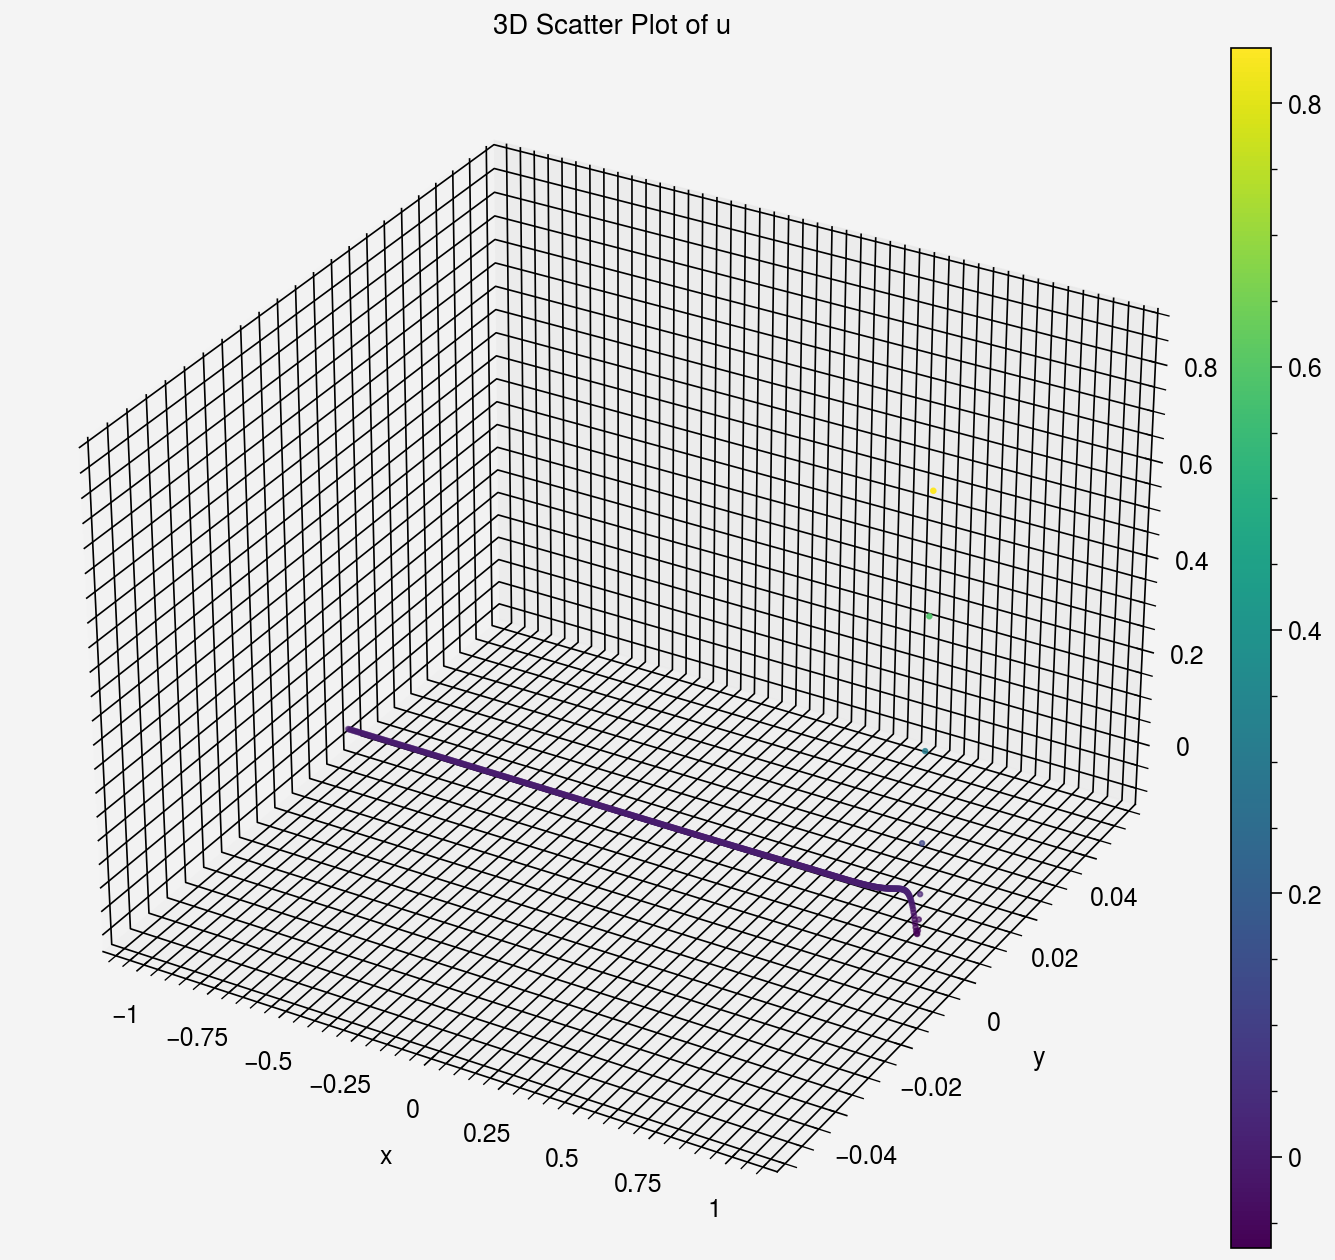

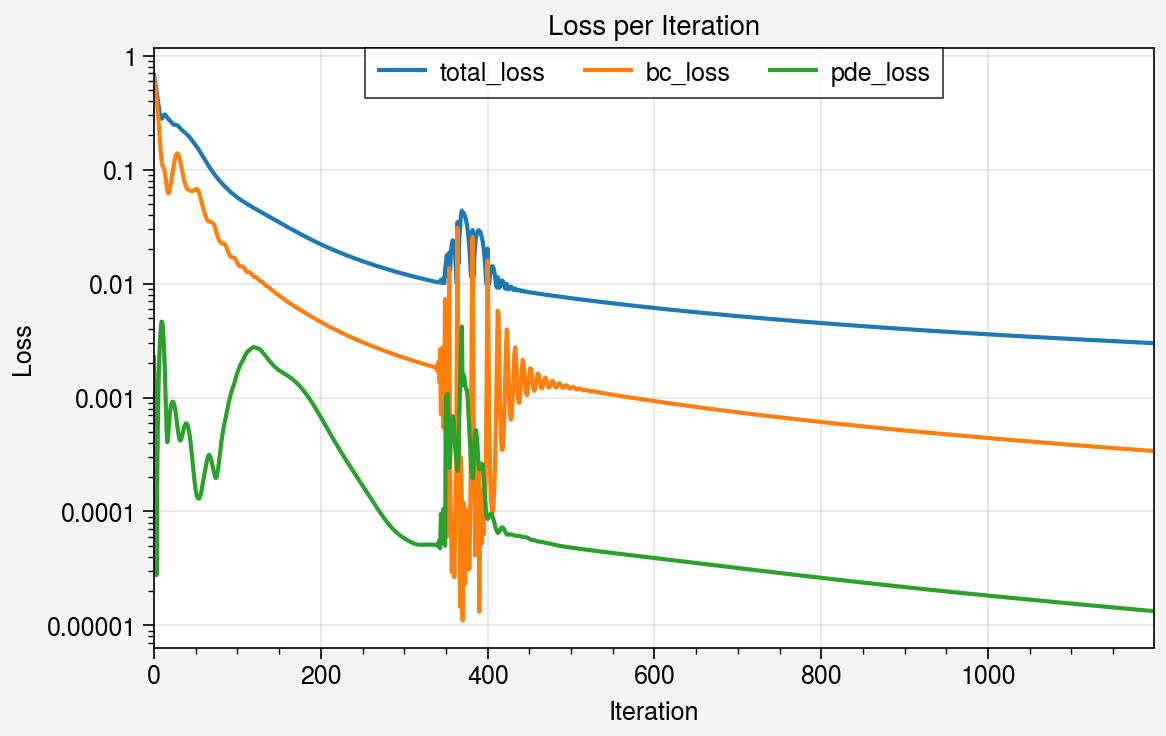

In [ ]:
# Evaluate the best model
prediction = domain.area_list[0].evaluate(model1)
prediction.define_time(0.1)
# Sampling uniform points
import numpy as np
prediction['pde_residual'] = np.clip(prediction['pde_residual'], 0, 0.09)
_ = prediction.plot('u')
_ = prediction.plot_loss_curve(log_scale=True)

C:\Users\thamm\OneDrive\Documents\1 - Projects\0 - STEM\2 - Numerical Physics\9 - PINNs\deepflow\src\deepflow\evaluation.py:172: UltraPlotWarning: fig.subplots_adjust() has no effect on ultraplot figures. To set the left, right, bottom, top, wspace, or hspace gridspec values, pass them as keyword arguments to uplt.figure() or uplt.subplots(). Please note they are now specified in physical units, with strings interpreted by uplt.units() and floats interpreted as font size-widths.
  fig.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)


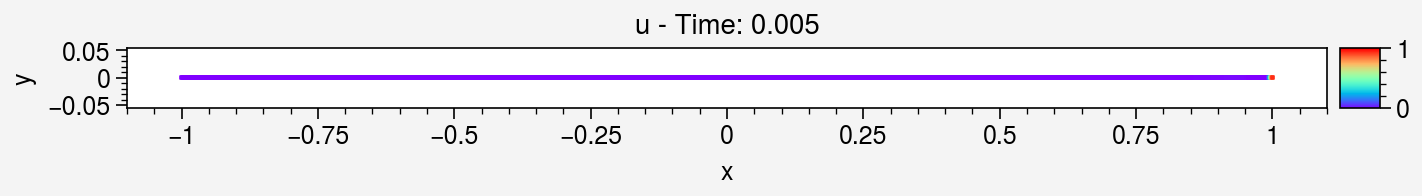

In [10]:
_ = prediction.plot_animate('u', range_t=[0.005, 1], dt = 0.1, frame_interval=100, cmap = 'rainbow', s=1, color_range=[-0,1])
_.save('u_evolution.gif', writer='pillow')

### 4.1 Visualize PDE area

C:\Users\thamm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\events.py:82: UltraPlotWarning: Tick label sharing not implemented for <class 'ultraplot.axes.three.ThreeAxes'> subplots.
  func(*args, **kwargs)
C:\Users\thamm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UltraPlotWarning: Tick label sharing not implemented for <class 'ultraplot.axes.three.ThreeAxes'> subplots.
  fig.canvas.print_figure(bytes_io, **kw)


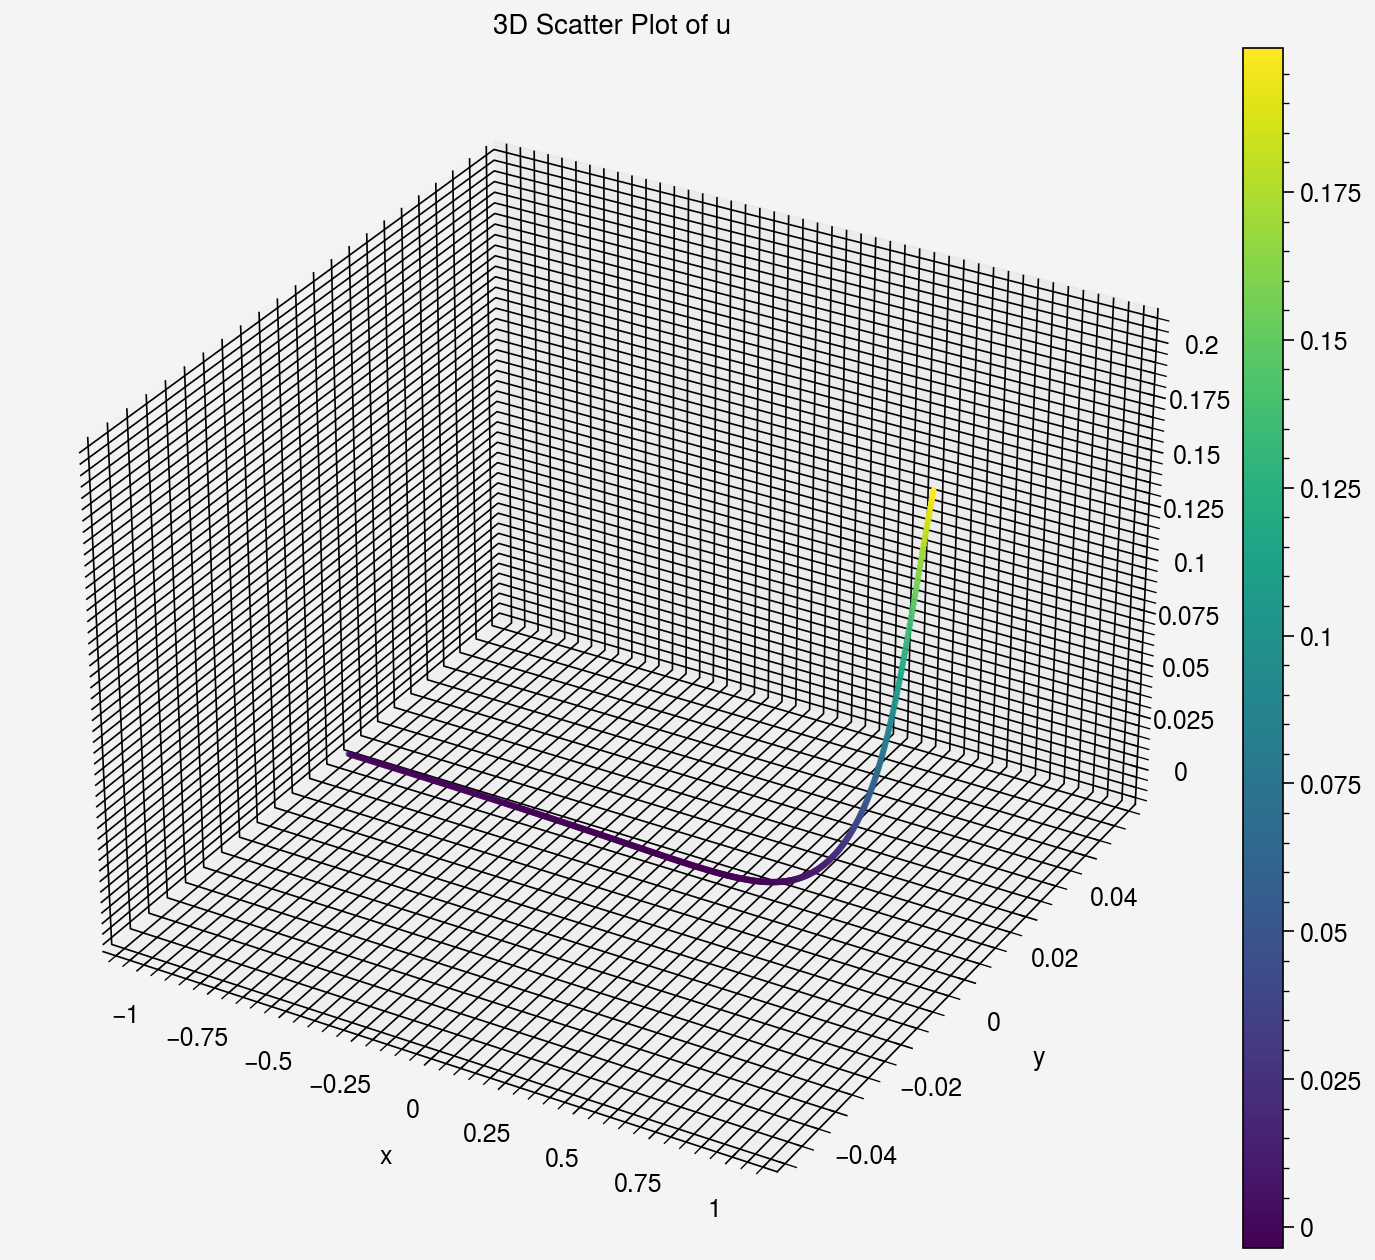

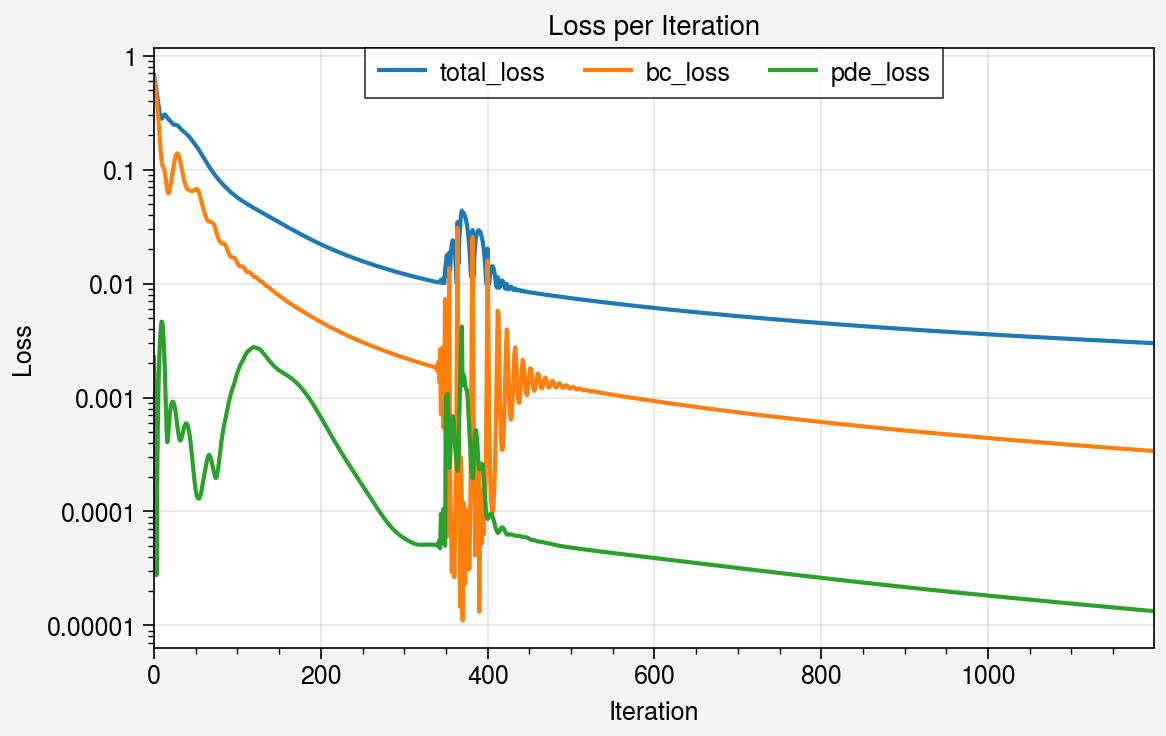

In [11]:
# Plot Velocity Field
# prediction.plot_color('u', cmap = 'jet', s=0.3).savefig('u_field.png')
# _ = prediction.plot_color('pde_residual', cmap = 'rainbow', s=0.3)
_ = prediction.plot('u')
_ = prediction.plot_loss_curve(log_scale=True)

### 4.2 Visualize u at y = 0.75

In [12]:
line = df.geometry.line_horizontal(y=0.75, range_x=[-1, 1])
prediction = line.evaluate(model2)
prediction.sampling_line(500)
_ = prediction.plot(y_axis = 'u')

NameError: name 'model2' is not defined